In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [3]:
# Data collection

df = pd.read_csv('fake_real_news_dataset.csv')

In [4]:
df

,article_id,title,content,author,source_credibility_score,num_citations,sentiment_score,clickbait_score,readability_score,label
0,1,tgdc xckafnafq klhwtekh yiccw gbldxchq jebruzw...,aigfywirkx ddtotlp fzncbc erpkpmgoy srngqclly ...,unknown_source,0.56,15,-0.51,0.26,70.63,real
1,2,glsgixcdj sbkok vkuya omyhkxvntu mhmkr kemdqak...,tbyf uqty vqgmc mgjpz cvzcairyk fpvgshruu ujlj...,staff_writer,0.15,2,-0.60,0.69,59.33,fake
2,3,oozhzrh wuzxtvxu pjqqr trdcqbuaj chted wjnhexy...,rpvycgawo fbvxhkdy zdgnkj sopsxrvqy ajlywc jxq...,staff_writer,0.83,6,0.07,0.12,72.34,real
3,4,froluunkef dgqwocvw celnvc vxykk gzjayv idaxmv...,vmnq gdlpgkrc bnnzok bkjtjbg qutiboveu zmedsya...,unknown_source,0.49,1,-0.42,0.64,68.57,fake
4,5,rtfvhoh qpgr fgcimrdz kywmf iqxcon waxkvyavu y...,mfcelget hrfpqklikc myajl yhsaqs rmer urqyjfym...,staff_writer,0.16,3,-0.02,0.68,77.65,fake
...,...,...,...,...,...,...,...,...,...,...
995,996,extdfxdogs jiywaybrok sesuuzjw dxpixcjuf tmlko...,xigokvuybx fcmi wybc ihrj oalocalt nnis cpukaw...,verified_journalist,0.31,0,-0.38,0.68,68.98,fake
996,997,mhmwkwnopw qjncecsum zkjysoq hjvorugm grjq ueu...,fcikyo aggln pzhewbprv rulz pthsrnmvh dhsmma o...,unknown_source,0.42,5,0.58,0.66,59.02,fake
997,998,geno tcjrekas gxswvebwoa alxlzgq gofnvk ybkf j...,sndawxf oufl qghkcvjntk dptmzoq slkrujraet qnk...,verified_journalist,0.68,3,0.26,0.27,57.16,real
998,999,ghcmm cejymxqehk qjuz ntdjnjyg exdlyafllp splm...,nokuid gwrde tenaa vesv uadwwvdzoy iiafhxs nec...,unknown_source,0.84,7,-0.24,0.39,45.79,real


In [5]:
df.shape

(1000, 10)

In [6]:
df.dtypes

article_id                    int64
title                           str
content                         str
author                          str
source_credibility_score    float64
num_citations                 int64
sentiment_score             float64
clickbait_score             float64
readability_score           float64
label                           str
dtype: object

In [7]:
df.head()

,article_id,title,content,author,source_credibility_score,num_citations,sentiment_score,clickbait_score,readability_score,label
0,1,tgdc xckafnafq klhwtekh yiccw gbldxchq jebruzw...,aigfywirkx ddtotlp fzncbc erpkpmgoy srngqclly ...,unknown_source,0.56,15,-0.51,0.26,70.63,real
1,2,glsgixcdj sbkok vkuya omyhkxvntu mhmkr kemdqak...,tbyf uqty vqgmc mgjpz cvzcairyk fpvgshruu ujlj...,staff_writer,0.15,2,-0.60,0.69,59.33,fake
2,3,oozhzrh wuzxtvxu pjqqr trdcqbuaj chted wjnhexy...,rpvycgawo fbvxhkdy zdgnkj sopsxrvqy ajlywc jxq...,staff_writer,0.83,6,0.07,0.12,72.34,real
3,4,froluunkef dgqwocvw celnvc vxykk gzjayv idaxmv...,vmnq gdlpgkrc bnnzok bkjtjbg qutiboveu zmedsya...,unknown_source,0.49,1,-0.42,0.64,68.57,fake
4,5,rtfvhoh qpgr fgcimrdz kywmf iqxcon waxkvyavu y...,mfcelget hrfpqklikc myajl yhsaqs rmer urqyjfym...,staff_writer,0.16,3,-0.02,0.68,77.65,fake


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   article_id                1000 non-null   int64  
 1   title                     1000 non-null   str    
 2   content                   1000 non-null   str    
 3   author                    1000 non-null   str    
 4   source_credibility_score  1000 non-null   float64
 5   num_citations             1000 non-null   int64  
 6   sentiment_score           1000 non-null   float64
 7   clickbait_score           1000 non-null   float64
 8   readability_score         1000 non-null   float64
 9   label                     1000 non-null   str    
dtypes: float64(4), int64(2), str(4)
memory usage: 547.5 KB


In [9]:
df.describe()

,article_id,source_credibility_score,num_citations,sentiment_score,clickbait_score,readability_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,0.450920,5.940000,0.057630,0.481570,60.584420
std,288.819436,0.251114,4.583384,0.581706,0.306351,11.417862
min,1.000000,0.000000,0.000000,-1.000000,0.000000,40.040000
25%,250.750000,0.260000,2.750000,-0.450000,0.200000,51.400000
50%,500.500000,0.430000,5.000000,0.100000,0.520000,59.900000
75%,750.250000,0.600000,10.000000,0.552500,0.770000,70.540000
max,1000.000000,1.000000,15.000000,1.000000,1.000000,80.000000


In [10]:
df.columns

Index(['article_id', 'title', 'content', 'author', 'source_credibility_score',
       'num_citations', 'sentiment_score', 'clickbait_score',
       'readability_score', 'label'],
      dtype='str')

In [11]:
df.nunique()

article_id                  1000
title                       1000
content                     1000
author                         3
source_credibility_score     101
num_citations                 16
sentiment_score              198
clickbait_score               92
readability_score            895
label                          2
dtype: int64

In [12]:
df['author'].value_counts()

author
staff_writer           340
unknown_source         332
verified_journalist    328
Name: count, dtype: int64

In [13]:
df.sample(5)        # random 5 rows

,article_id,title,content,author,source_credibility_score,num_citations,sentiment_score,clickbait_score,readability_score,label
545,546,wfilbbo cdzpxavla bpsuey aolkknplir acnhyjv rl...,hkfcy mupvaffnj yraoyg cgajsqgc gwipjeoi pbamg...,staff_writer,0.07,3,0.06,0.58,54.74,fake
369,370,tscj zfkm duzgn nytrqpl rqqwusxae ckhaaiexh vn...,nyduvsm paemjk zycw bkbmyjnl ddforswxs zlvmzqq...,verified_journalist,0.88,12,0.13,0.15,53.74,real
513,514,dobzvylegj gujxuyqf bhszuxyzox sofftbuf wluvbp...,gtkl wkierx aolfqut cebjzf teulupnrqs ouqljtqf...,unknown_source,0.59,4,0.99,0.06,42.72,real
110,111,ezcs ahjc xnkfxlifwa upkznvyj vgbkxbrk wcsgmuy...,oqzt jleinfxe oteciw llqttxcb bowsvp dzthjb ac...,verified_journalist,0.38,4,0.17,0.88,58.78,fake
658,659,tgzy pddxts bhndrltz gugblhwkda ddxjafeon fzib...,gpvyms nrrcnpiy vmggl pntwokviqk rebvpq rnajqo...,verified_journalist,0.08,0,0.60,0.58,64.87,fake


Data Cleaning 

In [14]:
df.isnull().sum()

article_id                  0
title                       0
content                     0
author                      0
source_credibility_score    0
num_citations               0
sentiment_score             0
clickbait_score             0
readability_score           0
label                       0
dtype: int64

In [19]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [17]:
df.head()

,article_id,title,content,author,source_credibility_score,num_citations,sentiment_score,clickbait_score,readability_score,label
0,1,tgdc xckafnafq klhwtekh yiccw gbldxchq jebruzw...,aigfywirkx ddtotlp fzncbc erpkpmgoy srngqclly ...,unknown_source,0.56,15,-0.51,0.26,70.63,real
1,2,glsgixcdj sbkok vkuya omyhkxvntu mhmkr kemdqak...,tbyf uqty vqgmc mgjpz cvzcairyk fpvgshruu ujlj...,staff_writer,0.15,2,-0.60,0.69,59.33,fake
2,3,oozhzrh wuzxtvxu pjqqr trdcqbuaj chted wjnhexy...,rpvycgawo fbvxhkdy zdgnkj sopsxrvqy ajlywc jxq...,staff_writer,0.83,6,0.07,0.12,72.34,real
3,4,froluunkef dgqwocvw celnvc vxykk gzjayv idaxmv...,vmnq gdlpgkrc bnnzok bkjtjbg qutiboveu zmedsya...,unknown_source,0.49,1,-0.42,0.64,68.57,fake
4,5,rtfvhoh qpgr fgcimrdz kywmf iqxcon waxkvyavu y...,mfcelget hrfpqklikc myajl yhsaqs rmer urqyjfym...,staff_writer,0.16,3,-0.02,0.68,77.65,fake


In [18]:
df = df.reset_index(drop=True)

Feature engineering

<Axes: >

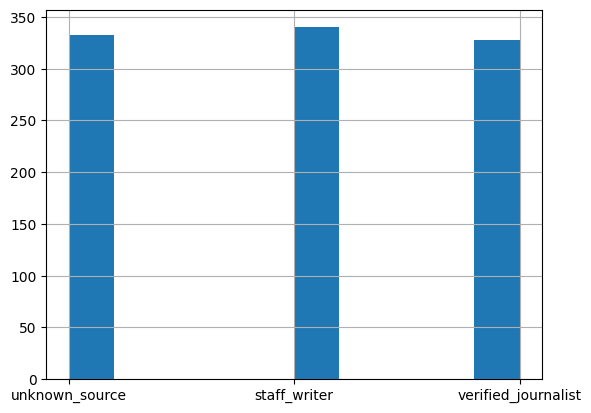

In [21]:
# A. Univariate Analysis

df['author'].value_counts()
df['author'].hist()

<Axes: xlabel='author', ylabel='readability_score'>

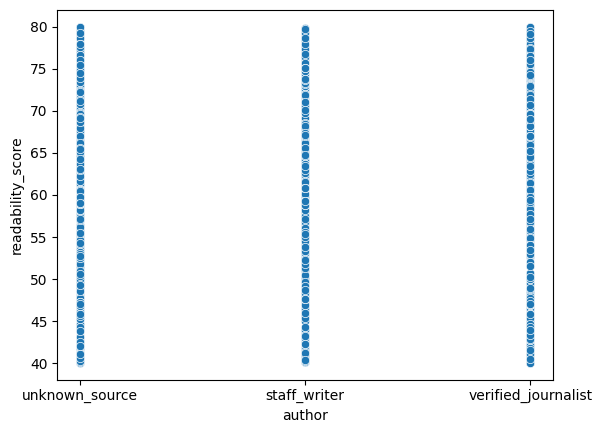

In [25]:
# B. Bivariate Analysis (2 variables)

df.groupby('author')['readability_score'].mean()
sns.scatterplot(x='author', y='readability_score', data=df)

<Axes: >

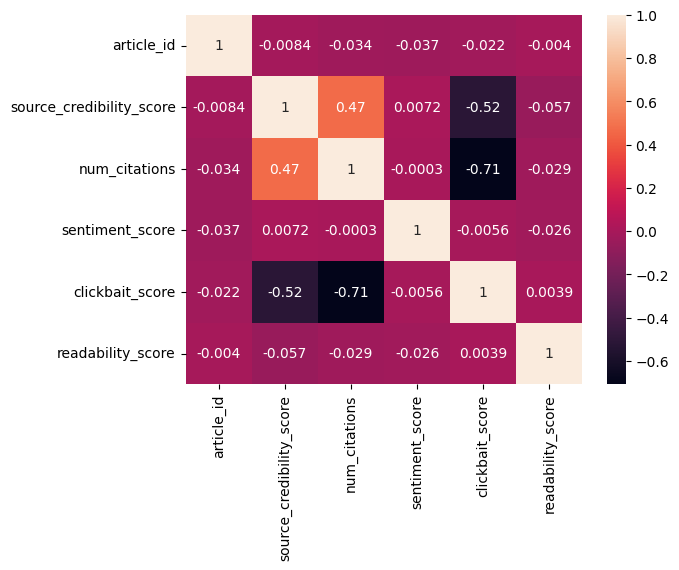

In [27]:
# C. Correlation

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True) 

<Axes: xlabel='source_credibility_score', ylabel='Count'>

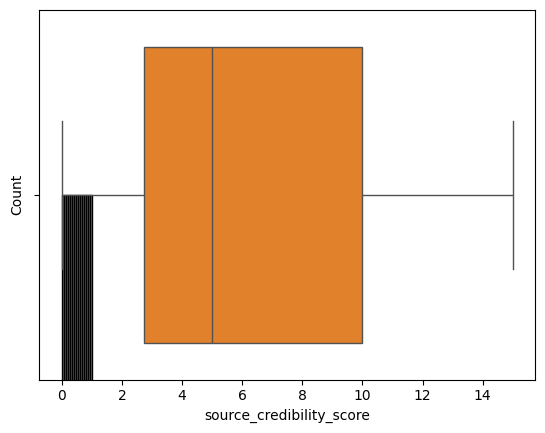

In [31]:
# D. Distributions
# Skewness
# Spread

sns.histplot(df['source_credibility_score'])
sns.boxplot(x=df['num_citations'])

<Axes: xlabel='author'>

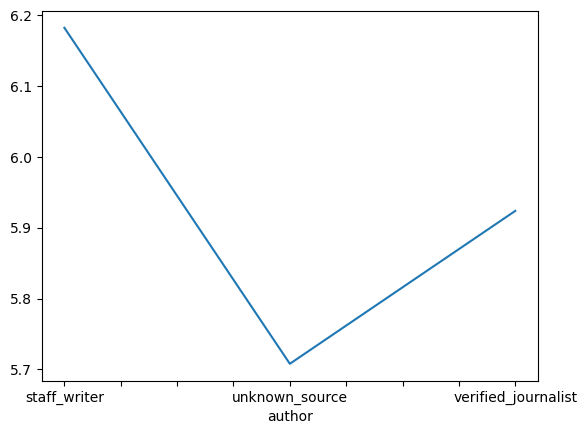

In [33]:
# E. Trends (if time data exists)

df.groupby('author')['num_citations'].mean().plot()